# Initial Dataset Observations

- Total Records: 318,438
- Total Features: 18

## Missing Values
- Bed Grade: 113
- City_Code_Patient: 4,532

## Duplicate Records
- No duplicate records found.

## Data Types
- Integer: 6
- Float: 3
- Object: 9

## Initial Conclusion
The dataset is clean overall, with only two features containing missing values. No duplicate records were found. The dataset is suitable for exploratory data analysis and machine learning after appropriate preprocessing.

In [5]:
import pandas as pd
import numpy as np


In [6]:
df = pd.read_csv("../data/raw/train_data.csv")
df.duplicated().sum()

np.int64(0)

In [7]:
df_clean = df.copy()

In [8]:
missing_percentage=(df_clean.isnull().sum() / len(df_clean))* 100
missing_percentage.sort_values(ascending=False)

City_Code_Patient                    1.423197
Bed Grade                            0.035486
Hospital_code                        0.000000
case_id                              0.000000
Hospital_region_code                 0.000000
Hospital_type_code                   0.000000
Available Extra Rooms in Hospital    0.000000
Department                           0.000000
Ward_Type                            0.000000
City_Code_Hospital                   0.000000
Ward_Facility_Code                   0.000000
patientid                            0.000000
Type of Admission                    0.000000
Severity of Illness                  0.000000
Visitors with Patient                0.000000
Age                                  0.000000
Admission_Deposit                    0.000000
Stay                                 0.000000
dtype: float64

In [9]:
df_clean["Bed Grade"] = df_clean["Bed Grade"].fillna(df_clean["Bed Grade"].mode()[0])
df_clean["City_Code_Patient"] = df_clean["City_Code_Patient"].fillna(
    df_clean["City_Code_Patient"].mode()[0]
)

In [10]:
df_clean.isnull().sum()
df_clean.to_csv("../data/processed/cleaned_train_data.csv",index=False)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [12]:
print(df_clean.shape)
df_clean.nunique()
df_clean.columns

(318438, 18)


Index(['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital',
       'Hospital_region_code', 'Available Extra Rooms in Hospital',
       'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed Grade',
       'patientid', 'City_Code_Patient', 'Type of Admission',
       'Severity of Illness', 'Visitors with Patient', 'Age',
       'Admission_Deposit', 'Stay'],
      dtype='str')

In [13]:
df_clean["Department"].unique()
df_clean["Hospital_type_code"].unique()
df_clean["Hospital_region_code"].unique()
df_clean["Ward_Type"].unique()
df_clean["Severity of Illness"].unique()
df_clean["Type of Admission"].unique()

<StringArray>
['Emergency', 'Trauma', 'Urgent']
Length: 3, dtype: str

In [14]:
df_clean["Stay"].value_counts()

Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-90                  4838
91-100                 2765
61-70                  2744
Name: count, dtype: int64

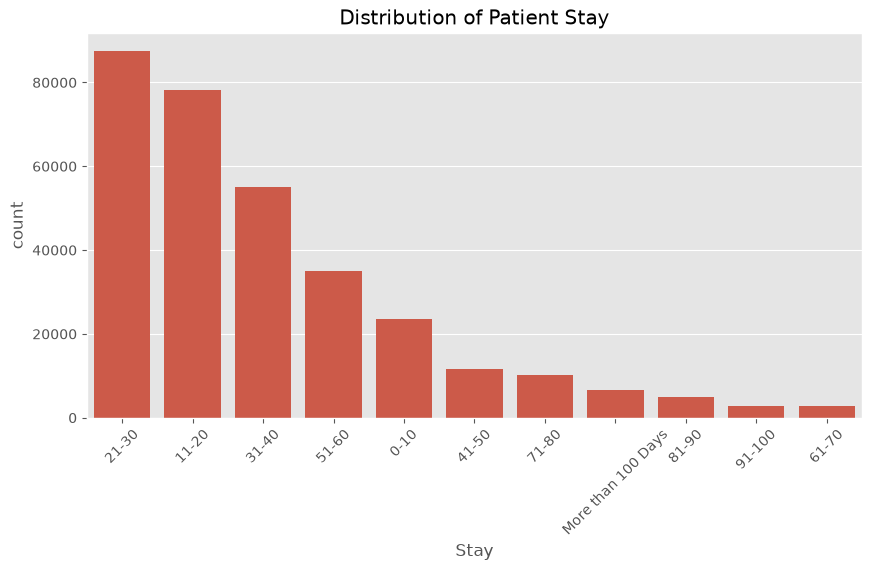

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Stay",
    order=df_clean["Stay"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Patient Stay")
plt.show()


## Observation
21-30 max 61-70 least

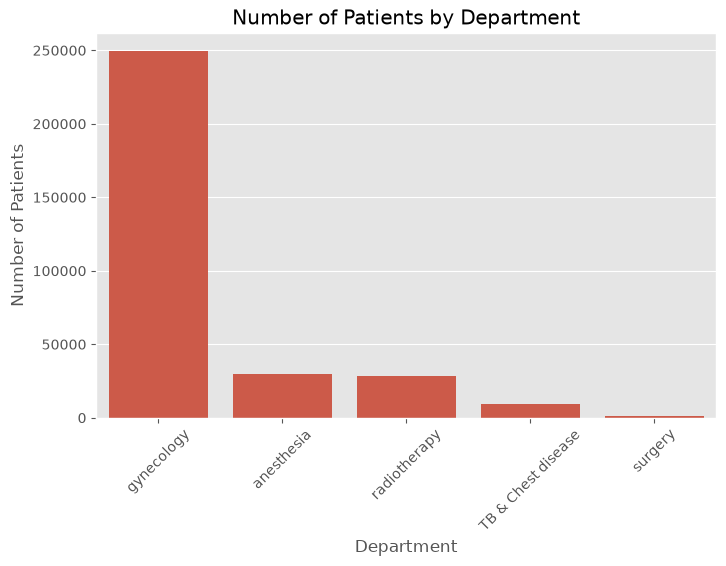

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Department",
    order=df_clean["Department"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Number of Patients by Department")
plt.xlabel("Department")
plt.ylabel("Number of Patients")

plt.show()

## Observation
gynecology has majority no of patients

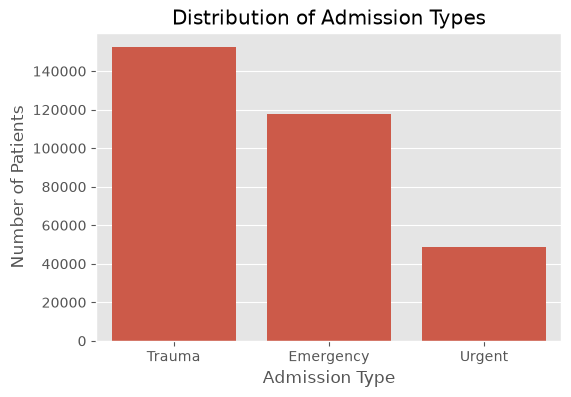

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="Type of Admission",
    order=df_clean["Type of Admission"].value_counts().index
)

plt.title("Distribution of Admission Types")
plt.xlabel("Admission Type")
plt.ylabel("Number of Patients")

plt.show()

## Observation
Trauma>Emergency>Urgent

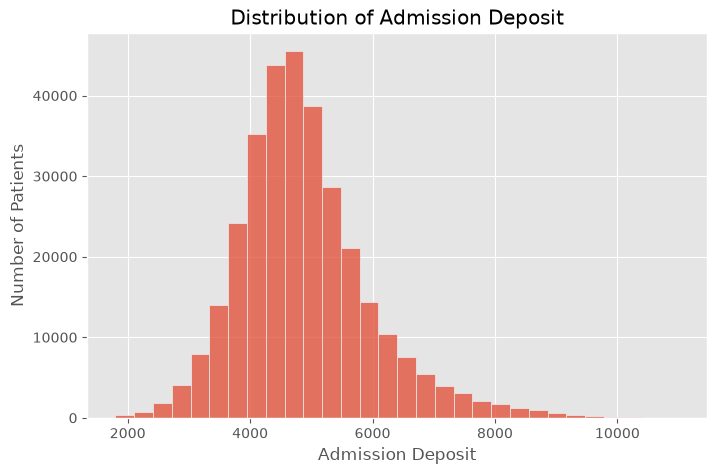

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Admission_Deposit",
    bins=30
)

plt.title("Distribution of Admission Deposit")
plt.xlabel("Admission Deposit")
plt.ylabel("Number of Patients")

plt.show()

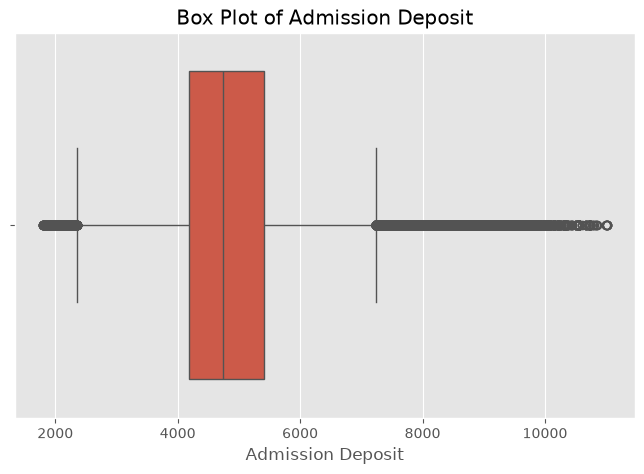

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Admission_Deposit"
)

plt.title("Box Plot of Admission Deposit")
plt.xlabel("Admission Deposit")

plt.show()

## Observation
- Majority 4200-5400
- Numerous high value outliners
- Only a few have low deposits
- Right Skewed

In [20]:
pd.crosstab(
    df_clean["Severity of Illness"],
    df_clean["Stay"]
)

Stay,0-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100,More than 100 Days
Severity of Illness,,,,,,,,,,,
Extreme,3399,10518,15502,10086,2351,7777,647,2575,1113,805,1950
Minor,7866,27081,21535,14447,3000,7128,519,1928,985,425,958
Moderate,12339,40540,50454,30626,6392,20113,1578,5751,2740,1535,3775


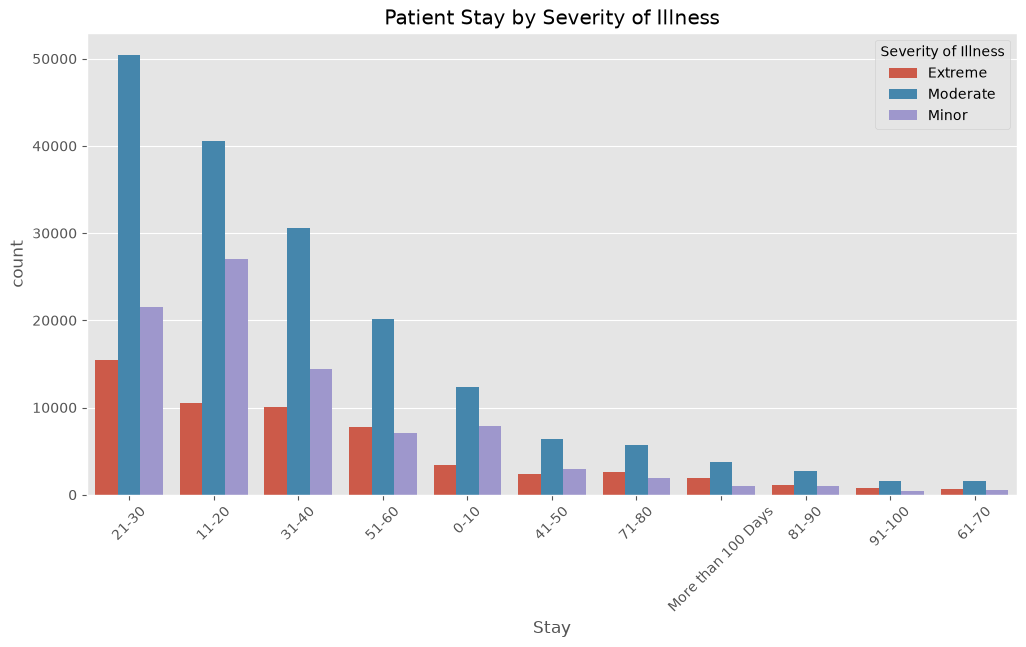

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_clean,
    x="Stay",
    hue="Severity of Illness",
    order=df_clean["Stay"].value_counts().index
)

plt.title("Patient Stay by Severity of Illness")
plt.xticks(rotation=45)

plt.show()

## Observation
- Max 21-30 days 
- Min 61-70 days 
- Major of the extreme severity patients stay for 21-30 days or near it 


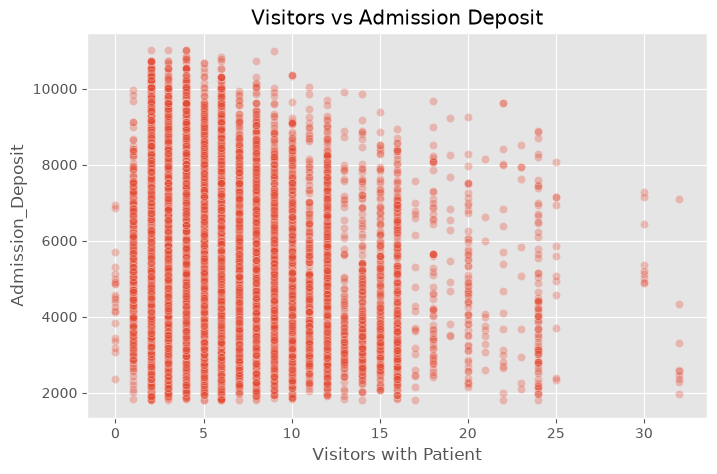

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Visitors with Patient",
    y="Admission_Deposit",
    alpha=0.3
)

plt.title("Visitors vs Admission Deposit")

plt.show()

## Observation

- No clear correlation is observed between the number of visitors and admission deposit.
- Patients with the same number of visitors have a wide range of deposit amounts.
- Most patients have between 2 and 10 visitors.
- Visitor count alone is unlikely to explain variations in admission deposits.

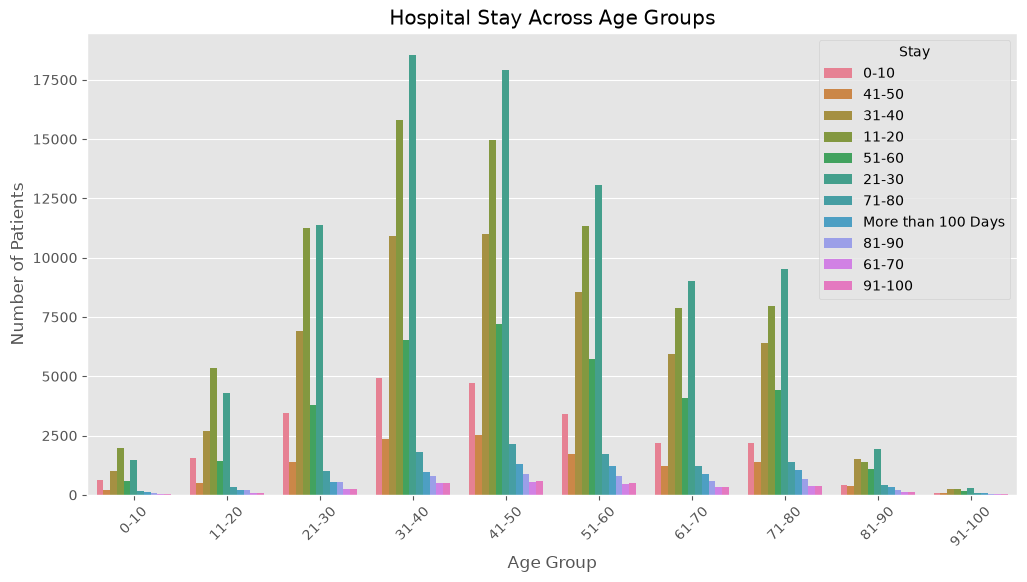

In [23]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_clean,
    x="Age",
    hue="Stay",
    order=sorted(df_clean["Age"].unique())
)

plt.title("Hospital Stay Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.show()

## Observation

- Middle-aged show a higher proportion of longer hospital stays.
- Younger patients less than 20 and older patients grater than 80  are more concentrated in shorter stay categories.
- Age appears to influence the duration of hospitalization and may be an important feature for predicting patient stay.

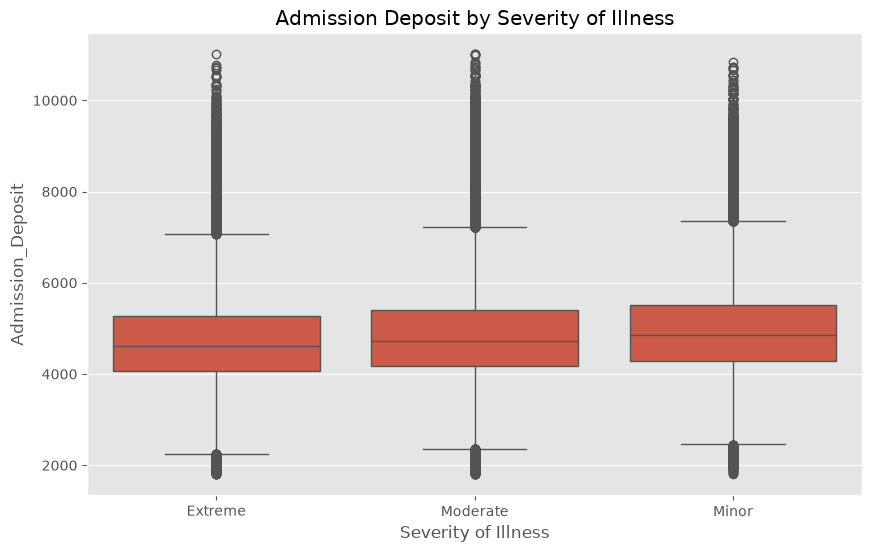

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="Severity of Illness",
    y="Admission_Deposit"
)

plt.title("Admission Deposit by Severity of Illness")

plt.show()

## Observation
- No major variation 

In [25]:
df_clean.select_dtypes(include="number").corr()

,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
case_id,1.000000,-0.043023,-0.011352,0.042580,0.013714,-0.004150,0.065207,0.001309,-0.045972
Hospital_code,-0.043023,1.000000,0.128294,-0.059638,-0.013374,0.002291,-0.015477,-0.028500,0.045446
City_Code_Hospital,-0.011352,0.128294,1.000000,-0.045771,-0.049400,0.000750,-0.024161,0.018184,-0.034455
Available Extra Rooms in Hospital,0.042580,-0.059638,-0.045771,1.000000,-0.115913,0.000921,-0.009462,0.096714,-0.143739
Bed Grade,0.013714,-0.013374,-0.049400,-0.115913,1.000000,0.001656,-0.007439,0.088950,0.073889
patientid,-0.004150,0.002291,0.000750,0.000921,0.001656,1.000000,0.002009,0.006889,-0.000877
City_Code_Patient,0.065207,-0.015477,-0.024161,-0.009462,-0.007439,0.002009,1.000000,-0.011677,0.025485
Visitors with Patient,0.001309,-0.028500,0.018184,0.096714,0.088950,0.006889,-0.011677,1.000000,-0.150358
Admission_Deposit,-0.045972,0.045446,-0.034455,-0.143739,0.073889,-0.000877,0.025485,-0.150358,1.000000


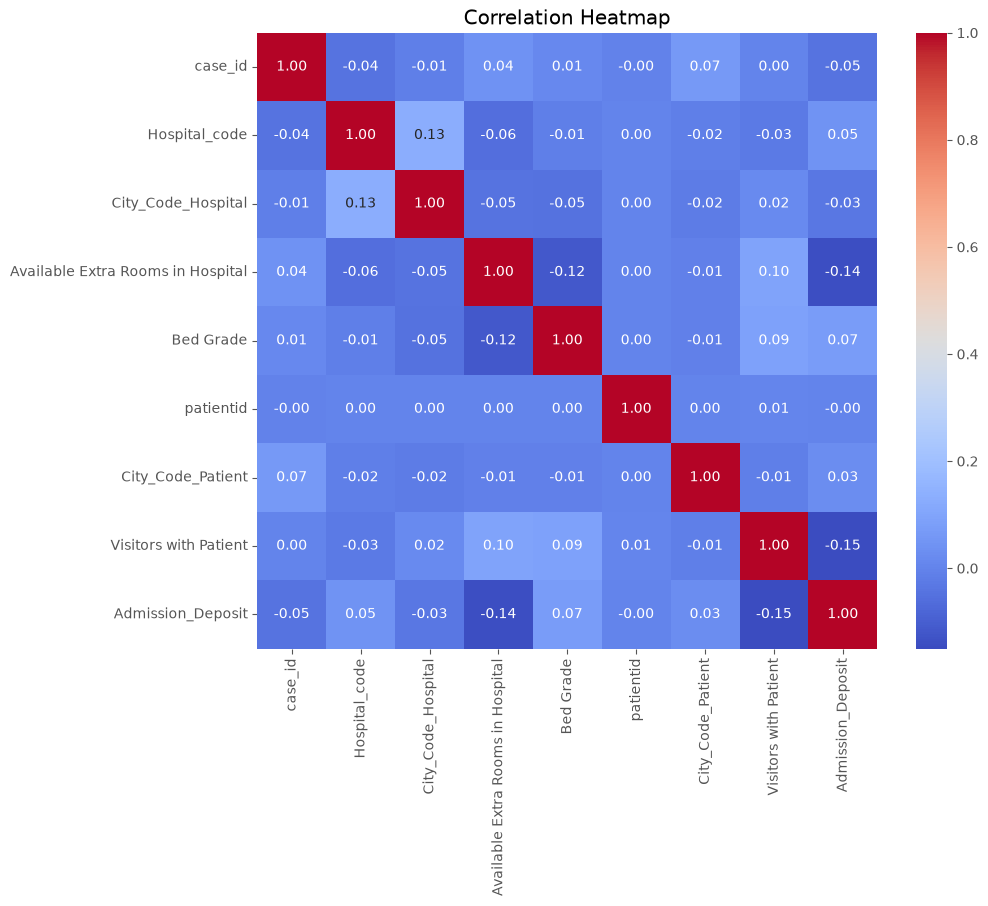

In [26]:
plt.figure(figsize=(10,8))
           
sns.heatmap(
    df_clean.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"   
)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
df_ml = df_clean.copy()

In [28]:
df_ml.drop(
    columns=["case_id","patientid"],
    inplace=True
)

In [29]:
df_ml.columns

Index(['Hospital_code', 'Hospital_type_code', 'City_Code_Hospital',
       'Hospital_region_code', 'Available Extra Rooms in Hospital',
       'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed Grade',
       'City_Code_Patient', 'Type of Admission', 'Severity of Illness',
       'Visitors with Patient', 'Age', 'Admission_Deposit', 'Stay'],
      dtype='str')

In [30]:
X=df_ml.drop("Stay",axis=1)   #axis =0 rows   axis=1 columns

In [31]:
Y=df_ml["Stay"]

In [32]:
Y.head()
print(Y.shape) #y is not a DataFrame anymore. It's a Series. A Series is a one-dimensional structure.

(318438,)


In [33]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()

In [34]:
df_ml["Age"] = label_encoder.fit_transform(df_ml["Age"])

In [35]:
df_ml["Age"]


0         5
1         5
2         5
3         5
4         5
         ..
318433    4
318434    8
318435    7
318436    1
318437    1
Name: Age, Length: 318438, dtype: int64

In [38]:
nominal_columns = [
    "Hospital_type_code",
    "Hospital_region_code",
    "Department",
    "Ward_Type",
    "Ward_Facility_Code",
    "Type of Admission"
]

In [ ]:
df_ml = pd.get_dummies(
    df_ml,
    columns=nominal_columns,
    dtype=int
)

In [41]:
print(df_ml.columns.tolist())

['Hospital_code', 'City_Code_Hospital', 'Available Extra Rooms in Hospital', 'Bed Grade', 'City_Code_Patient', 'Severity of Illness', 'Visitors with Patient', 'Age', 'Admission_Deposit', 'Stay', 'Hospital_type_code_a', 'Hospital_type_code_b', 'Hospital_type_code_c', 'Hospital_type_code_d', 'Hospital_type_code_e', 'Hospital_type_code_f', 'Hospital_type_code_g', 'Hospital_region_code_X', 'Hospital_region_code_Y', 'Hospital_region_code_Z', 'Department_TB & Chest disease', 'Department_anesthesia', 'Department_gynecology', 'Department_radiotherapy', 'Department_surgery', 'Ward_Type_P', 'Ward_Type_Q', 'Ward_Type_R', 'Ward_Type_S', 'Ward_Type_T', 'Ward_Type_U', 'Ward_Facility_Code_A', 'Ward_Facility_Code_B', 'Ward_Facility_Code_C', 'Ward_Facility_Code_D', 'Ward_Facility_Code_E', 'Ward_Facility_Code_F', 'Type of Admission_Emergency', 'Type of Admission_Trauma', 'Type of Admission_Urgent']


In [45]:
df_ml.columns

Index(['Hospital_code', 'City_Code_Hospital',
       'Available Extra Rooms in Hospital', 'Bed Grade', 'City_Code_Patient',
       'Severity of Illness', 'Visitors with Patient', 'Age',
       'Admission_Deposit', 'Stay', 'Hospital_type_code_a',
       'Hospital_type_code_b', 'Hospital_type_code_c', 'Hospital_type_code_d',
       'Hospital_type_code_e', 'Hospital_type_code_f', 'Hospital_type_code_g',
       'Hospital_region_code_X', 'Hospital_region_code_Y',
       'Hospital_region_code_Z', 'Department_TB & Chest disease',
       'Department_anesthesia', 'Department_gynecology',
       'Department_radiotherapy', 'Department_surgery', 'Ward_Type_P',
       'Ward_Type_Q', 'Ward_Type_R', 'Ward_Type_S', 'Ward_Type_T',
       'Ward_Type_U', 'Ward_Facility_Code_A', 'Ward_Facility_Code_B',
       'Ward_Facility_Code_C', 'Ward_Facility_Code_D', 'Ward_Facility_Code_E',
       'Ward_Facility_Code_F', 'Type of Admission_Emergency',
       'Type of Admission_Trauma', 'Type of Admission_Urgent'],
 

In [47]:
X = df_ml.drop("Stay", axis=1)
y = df_ml["Stay"]

In [48]:
print(X.shape)
print(y.shape)

(318438, 39)
(318438,)


In [49]:
df_ml[["Severity of Illness","Bed Grade"]].dtypes

Severity of Illness        str
Bed Grade              float64
dtype: object

In [50]:
df_ml["Bed Grade"]=df_ml["Bed Grade"].astype(int)

In [51]:
severity_encoder=LabelEncoder()
df_ml["Severity of Illness"]=severity_encoder.fit_transform(
    df_ml["Severity of Illness"]
)

In [52]:
severity_encoder.classes_

array(['Extreme', 'Minor', 'Moderate'], dtype=object)

In [53]:
df_ml[["Severity of Illness", "Bed Grade"]].head()

,Severity of Illness,Bed Grade
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(254750, 39)
(63688, 39)
(254750,)
(63688,)


In [57]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
model=DecisionTreeClassifier(random_state=42)

In [60]:
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Moderate'

In [61]:
print(X_train.select_dtypes(include="object").columns)

Index(['Severity of Illness'], dtype='str')


C:\Users\namay\AppData\Local\Temp\ipykernel_31980\2453056806.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include="object").columns)


In [62]:
severity_mapping = {
    "Minor": 0,
    "Moderate": 1,
    "Extreme": 2
}

df_ml["Severity of Illness"] = df_ml["Severity of Illness"].map(severity_mapping)

In [63]:
X = df_ml.drop("Stay", axis=1)
y = df_ml["Stay"]

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [65]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [66]:
y_pred = model.predict(X_test)

In [72]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy=accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.29369739982414267


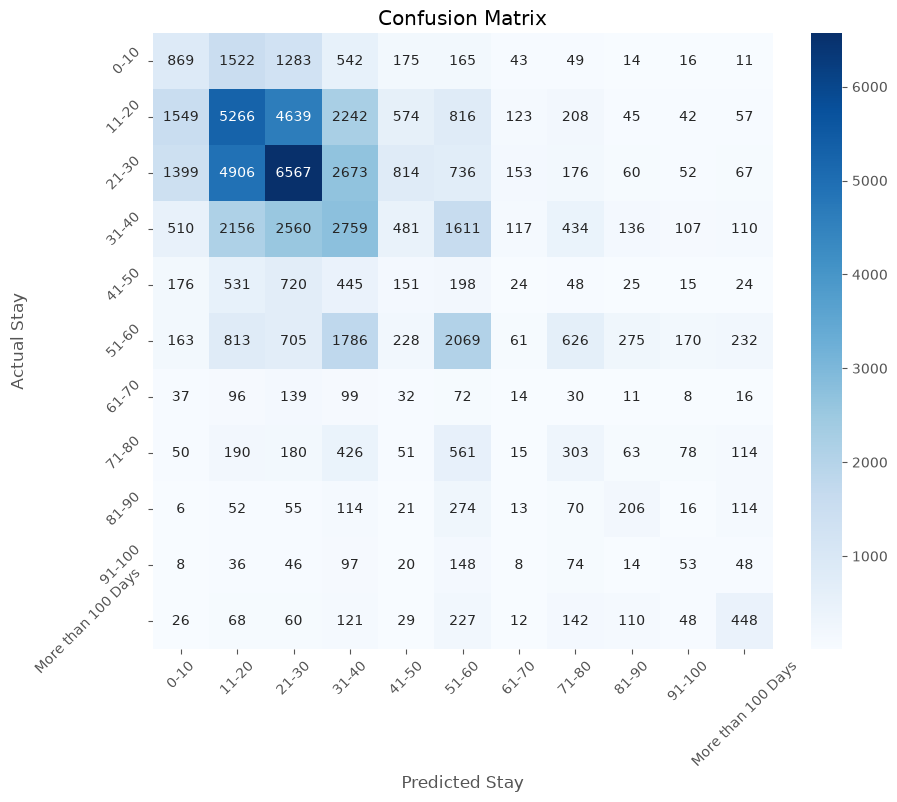

In [76]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
import matplotlib.pyplot as plt
import seaborn as sns

stay_labels = sorted(df_clean["Stay"].unique())

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=stay_labels,
    yticklabels=stay_labels
)

plt.xlabel("Predicted Stay")
plt.ylabel("Actual Stay")
plt.title("Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.show()

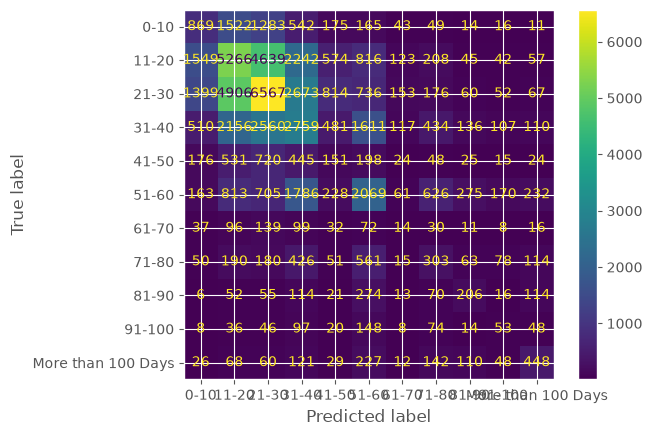

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [69]:
y_pred[:10]

array(['11-20', '51-60', '21-30', '0-10', '21-30', '11-20', '31-40',
       '0-10', '21-30', '21-30'], dtype=object)

In [70]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
245328,51-60,11-20
239123,51-60,51-60
280646,21-30,21-30
89025,21-30,0-10
517,31-40,21-30
275285,31-40,11-20
221020,More than 100 Days,31-40
297989,11-20,0-10
128961,0-10,21-30
208348,11-20,21-30


In [ ]:
from sklearn.metrics import precision_score



print("Precision:",precision)

Precision: 0.29655289738593554


In [79]:
from sklearn.metrics import precision_score,recall_score,f1_score

precision=precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall=recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1=f1_score(
    y_test,
    y_pred,
    average="weighted"
)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.2966
Recall    : 0.2937
F1 Score  : 0.2951


In [80]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

              0-10       0.18      0.19      0.18      4689
             11-20       0.34      0.34      0.34     15561
             21-30       0.39      0.37      0.38     17603
             31-40       0.24      0.25      0.25     10981
             41-50       0.06      0.06      0.06      2357
             51-60       0.30      0.29      0.30      7128
             61-70       0.02      0.03      0.02       554
             71-80       0.14      0.15      0.14      2031
             81-90       0.21      0.22      0.22       941
            91-100       0.09      0.10      0.09       552
More than 100 Days       0.36      0.35      0.35      1291

          accuracy                           0.29     63688
         macro avg       0.21      0.21      0.21     63688
      weighted avg       0.30      0.29      0.30     63688



In [81]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

In [82]:
import pandas as pd
report_df=pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
0-10,0.181306,0.185327,0.183295,4689.000000
11-20,0.336787,0.338410,0.337597,15561.000000
21-30,0.387342,0.373061,0.380068,17603.000000
31-40,0.244073,0.251252,0.247611,10981.000000
41-50,0.058618,0.064064,0.061220,2357.000000
51-60,0.300858,0.290264,0.295466,7128.000000
61-70,0.024014,0.025271,0.024626,554.000000
71-80,0.140278,0.149188,0.144596,2031.000000
81-90,0.214807,0.218916,0.216842,941.000000
91-100,0.087603,0.096014,0.091616,552.000000


In [83]:
import joblib

In [84]:
joblib.dump(
    model,
    "decision_tree_model.pkl"
)

['decision_tree_model.pkl']

In [85]:
loaded_model = joblib.load(
    "decision_tree_model.pkl"
)

print(loaded_model)

DecisionTreeClassifier(random_state=42)
